In [6]:
%pip install -q matplotlib numpy pandas scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

from src.constants import MODEL_FEATURE_COLUMNS, OUTPUT_DIR

In [8]:


def run_cross_validation(
    df: pd.DataFrame,
    estimator,
    n_splits: int = 5,
):
    X = df[MODEL_FEATURE_COLUMNS]
    y = df["label"]

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    scores = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "roc_auc", "precision", "recall", "f1"],
    )

    fold_results = pd.DataFrame({
        metric.removeprefix("test_"): values
        for metric, values in scores.items()
        if metric.startswith("test_")
    })
    fold_results.index = range(1, n_splits + 1)
    fold_results.index.name = "fold"

    print(fold_results.round(4))
    print("\nMittelwert ± Standardabweichung")
    for metric in fold_results.columns:
        print(
            f"{metric}: {fold_results[metric].mean():.4f} "
            f"± {fold_results[metric].std():.4f}"
        )

    return fold_results


final_llama = pd.read_csv(OUTPUT_DIR / "final" / "final_llama.csv")
final_qwen = pd.read_csv(OUTPUT_DIR / "final" / "final_qwen.csv")

models = {
    "Logistische Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000),
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}
datasets = {
    "Llama": final_llama,
    "Qwen": final_qwen,
}

cv_results = {}
for dataset_name, dataset in datasets.items():
    for model_name, estimator in models.items():
        print(f"\n{dataset_name} – {model_name} (n={len(dataset)})")
        cv_results[(dataset_name, model_name)] = run_cross_validation(
            dataset,
            estimator,
        )


Llama – Logistische Regression (n=100)
      accuracy  roc_auc  precision  recall      f1
fold                                              
1         0.75   0.8586     0.8333  0.5556  0.6667
2         0.50   0.6566     0.4286  0.3333  0.3750
3         0.65   0.5859     0.6250  0.5556  0.5882
4         0.65   0.6970     0.6000  0.6667  0.6316
5         0.60   0.6364     0.5455  0.6667  0.6000

Mittelwert ± Standardabweichung
accuracy: 0.6300 ± 0.0908
roc_auc: 0.6869 ± 0.1040
precision: 0.6065 ± 0.1477
recall: 0.5556 ± 0.1361
f1: 0.5723 ± 0.1144

Llama – Random Forest (n=100)
      accuracy  roc_auc  precision  recall      f1
fold                                              
1         0.85   0.9091     0.8750  0.7778  0.8235
2         0.60   0.7374     0.5556  0.5556  0.5556
3         0.50   0.6061     0.4615  0.6667  0.5455
4         0.60   0.6364     0.5556  0.5556  0.5556
5         0.60   0.6364     0.5455  0.6667  0.6000

Mittelwert ± Standardabweichung
accuracy: 0.6300 ± 0.1304
r

## Linearitätsdiagnose der Modellfeatures

Die logistische Regression nimmt einen linearen Zusammenhang zwischen jedem Feature und den Log-Odds von `CG` an. Die Punkte zeigen die beobachteten Log-Odds; die gestrichelte Linie zeigt die lineare Annahme.

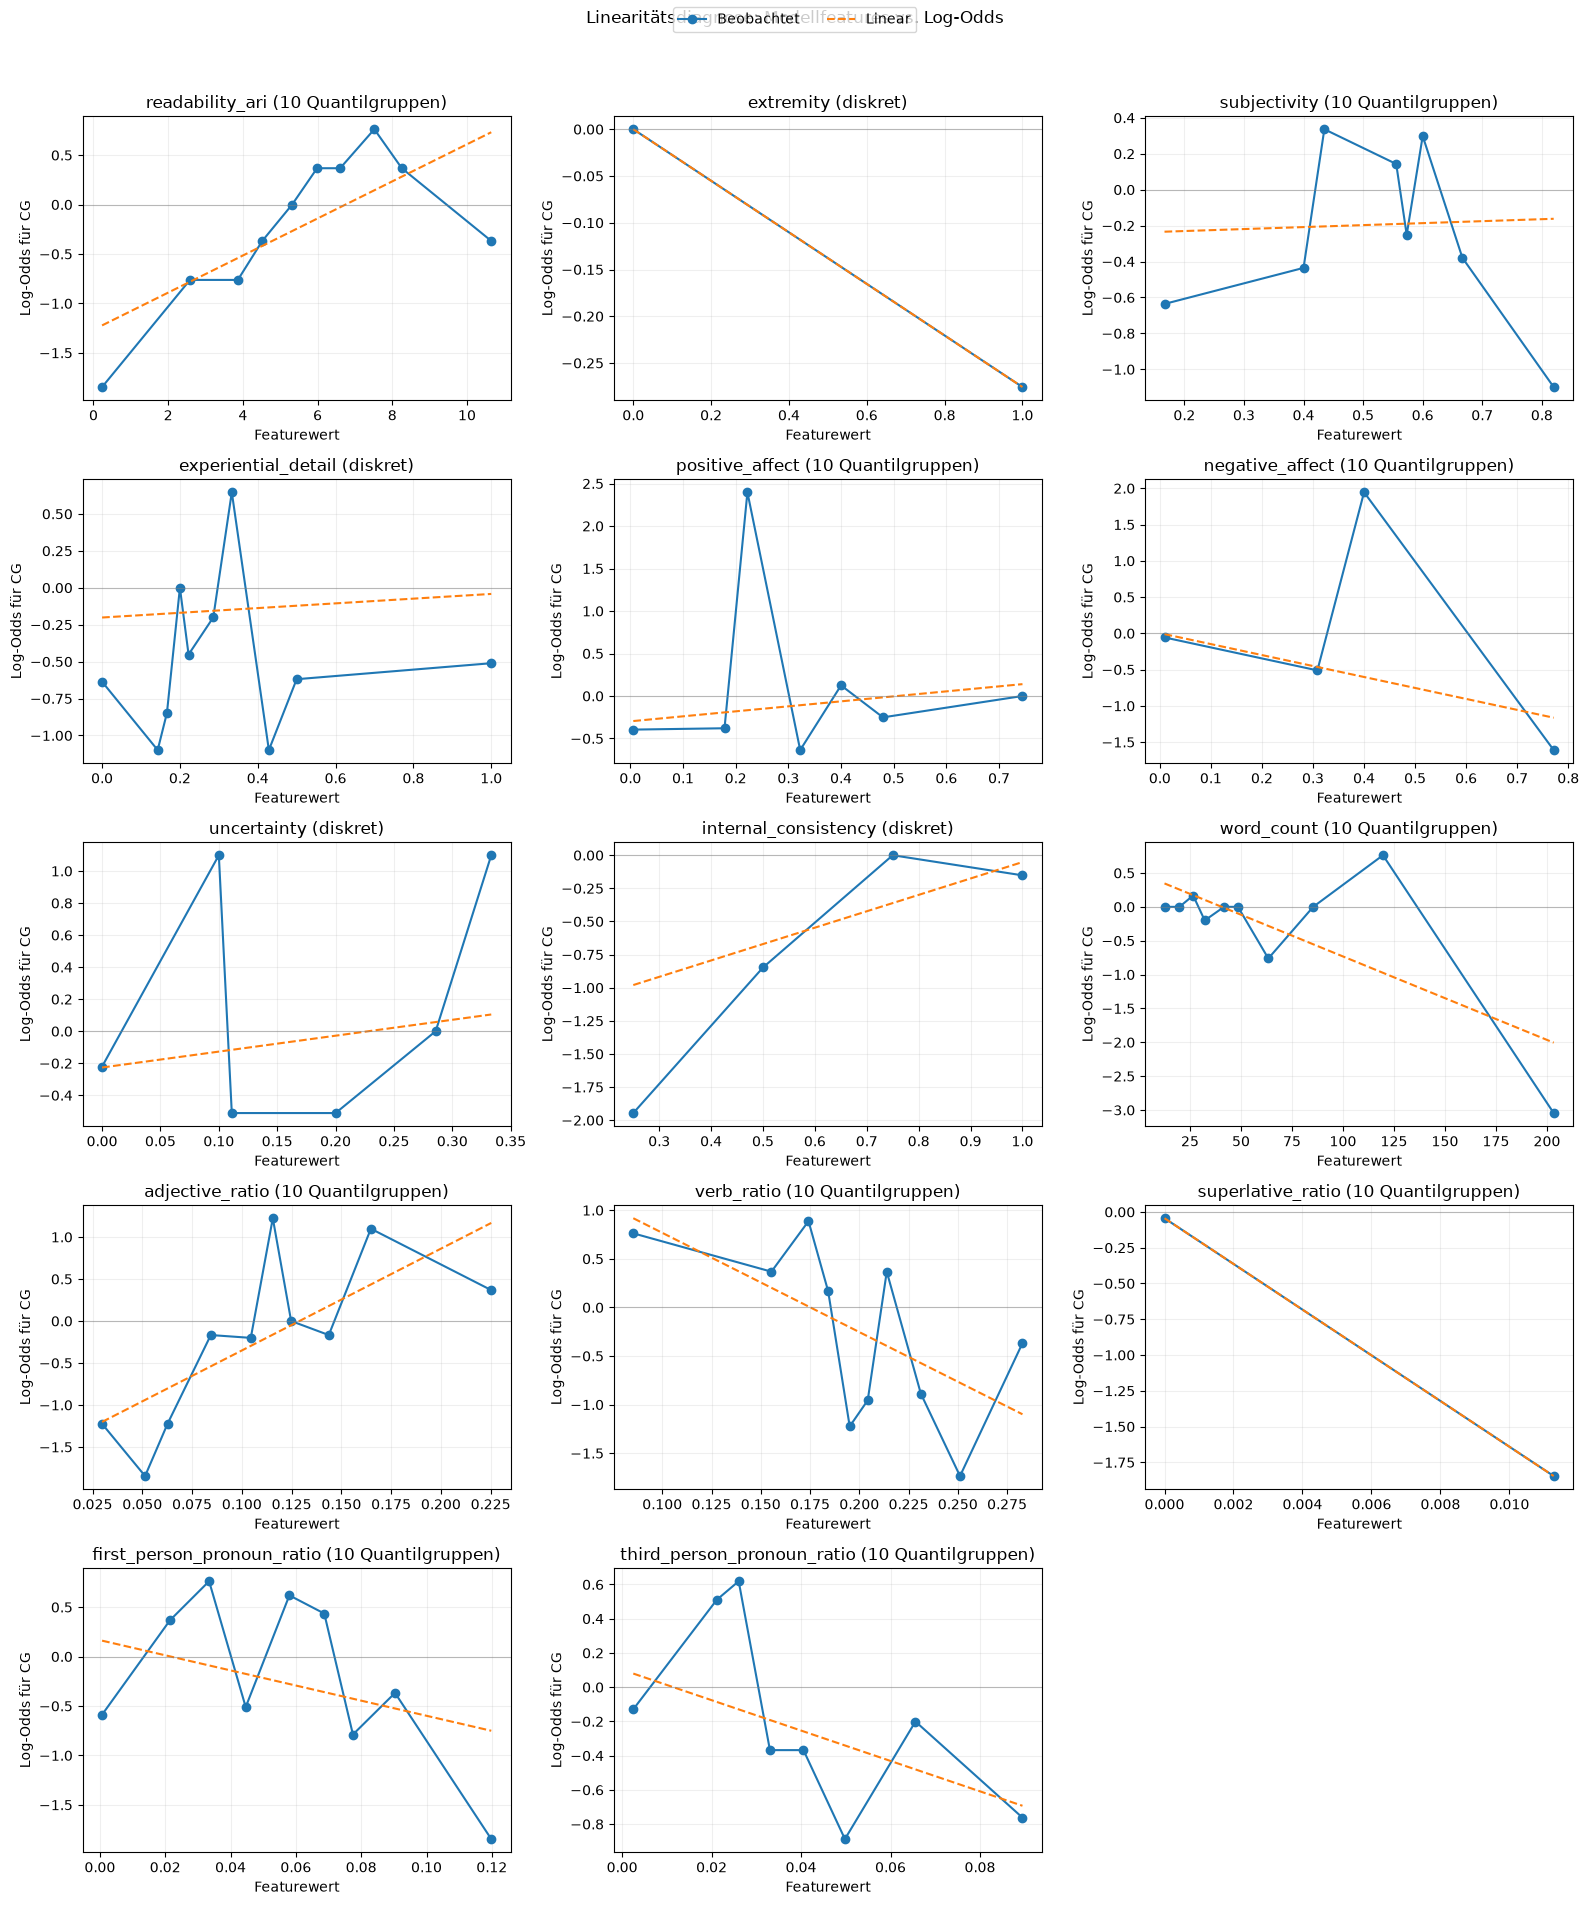

In [9]:
import math

import matplotlib.pyplot as plt
import numpy as np


def calculate_log_odds_summary(
    df: pd.DataFrame,
    feature: str,
    bins: int = 10,
) -> tuple[pd.DataFrame, bool]:
    feature_df = df[[feature, "label"]].dropna().copy()
    is_discrete = feature_df[feature].nunique() <= bins

    if is_discrete:
        feature_df["feature_group"] = feature_df[feature]
    else:
        feature_df["feature_group"] = pd.qcut(
            feature_df[feature],
            q=bins,
            duplicates="drop",
        )

    summary = (
        feature_df
        .groupby("feature_group", observed=True)
        .agg(
            feature_mean=(feature, "mean"),
            positive_count=("label", "sum"),
            sample_count=("label", "size"),
        )
        .reset_index(drop=True)
        .sort_values("feature_mean")
    )

    # Die 0.5-Korrektur verhindert unendliche Log-Odds bei Anteilen von 0 oder 1.
    probability = (
        summary["positive_count"] + 0.5
    ) / (
        summary["sample_count"] + 1
    )
    summary["log_odds"] = np.log(probability / (1 - probability))

    return summary, is_discrete


def plot_all_feature_linearities(
    df: pd.DataFrame,
    features: list[str],
    bins: int = 10,
):
    column_count = 3
    row_count = math.ceil(len(features) / column_count)
    figure, axes = plt.subplots(
        row_count,
        column_count,
        figsize=(16, 3.8 * row_count),
    )
    axes = np.atleast_1d(axes).ravel()

    for axis, feature in zip(axes, features):
        summary, is_discrete = calculate_log_odds_summary(
            df,
            feature,
            bins=bins,
        )
        x_values = summary["feature_mean"].to_numpy()
        y_values = summary["log_odds"].to_numpy()

        axis.plot(
            x_values,
            y_values,
            marker="o",
            label="Beobachtet",
        )

        if len(np.unique(x_values)) >= 2:
            coefficients = np.polyfit(
                x_values,
                y_values,
                deg=1,
                w=np.sqrt(summary["sample_count"]),
            )
            axis.plot(
                x_values,
                np.polyval(coefficients, x_values),
                linestyle="--",
                label="Linear",
            )

        feature_type = "diskret" if is_discrete else "10 Quantilgruppen"
        axis.set_title(f"{feature} ({feature_type})")
        axis.set_xlabel("Featurewert")
        axis.set_ylabel("Log-Odds für CG")
        axis.axhline(0, color="grey", linewidth=0.8, alpha=0.5)
        axis.grid(alpha=0.2)

    for axis in axes[len(features):]:
        axis.remove()

    handles, labels = axes[0].get_legend_handles_labels()
    figure.legend(handles, labels, loc="upper center", ncol=2)
    figure.suptitle("Linearitätsdiagnose: Modellfeatures vs. Log-Odds", y=1.0)
    figure.tight_layout(rect=(0, 0, 1, 0.98))
    plt.show()


plot_all_feature_linearities(final_llama, MODEL_FEATURE_COLUMNS)